# 🎓 Predicting Student Mental Health Score from Social Media Usage — Improved Model

**Goal:** improve the original regression notebook while keeping the analysis interpretable and reproducible.

### What was changed
- Keep the original exploratory analysis and data-cleaning logic.
- Keep all 111 `Country` categories instead of collapsing them to Top 10 + `Other`; the original grouping discarded useful signal in this dataset.
- Use a separate preprocessing strategy for linear regression and tree models.
- Add stronger nonlinear models, especially **Extra Trees Regressor**.
- Compare models using **R², MAE and RMSE** rather than calling R² “accuracy”.
- Add cross-validation code so the selected model is not judged only by one train/test split.
- Add feature importance and residual/error analysis.
- Save the complete final preprocessing + model pipeline for deployment.

> **Verified benchmark on the supplied data:** with the same 70/30 split (`random_state=42`), Extra Trees with all country categories achieved about **R² = 0.942**, compared with about **0.912** for Random Forest under the same representation. Your original Random Forest setup was about **0.879**.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import joblib

## 2. Load and Inspect the Dataset

In [2]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")

print("Shape:", df.shape)
display(df.head())
display(df.describe(include="all").T)

Shape: (5000, 13)


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,5000.0,NaN,NaN,NaN,20.8218,1.73662,18.0,19.0,21.0,22.0,24.0
Gender,5000,2,Male,2635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,5000,111,Other,1880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic_Level,5000,3,Undergraduate,3632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Most_Used_Platform,5000,12,Instagram,1130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purpose_Of_Use,5000,4,Entertainment,2552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg_Daily_Usage_Hours,5000.0,NaN,NaN,NaN,5.07846,1.653913,1.0,3.8,5.0,6.3,8.8
Daily_Unlocks,5000.0,NaN,NaN,NaN,171.4526,42.858254,62.0,140.0,171.0,204.0,273.0
Study_Hours,5000.0,NaN,NaN,NaN,3.00842,1.637018,0.3,1.5,2.8,4.2,8.3
Physical_Activity_Hours,5000.0,NaN,NaN,NaN,1.751,0.668398,-0.4,1.3,1.7,2.2,4.1


In [3]:
print("Missing values:")
display(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Data types:")
display(df.dtypes)

Missing values:


,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


Duplicate rows: 2
Data types:


,0
Age,int64
Gender,object
Country,object
Academic_Level,object
Most_Used_Platform,object
Purpose_Of_Use,object
Avg_Daily_Usage_Hours,float64
Daily_Unlocks,int64
Study_Hours,float64
Physical_Activity_Hours,float64


## 3. Exploratory Data Analysis

These plots retain the useful parts of the original notebook while avoiding unnecessary chart repetition.

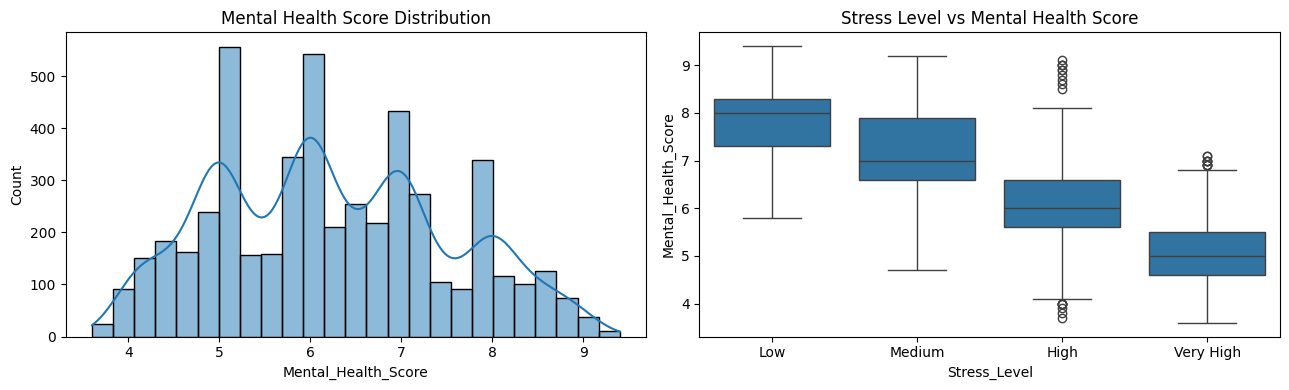

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["Mental_Health_Score"], kde=True, ax=axes[0])
axes[0].set_title("Mental Health Score Distribution")

sns.boxplot(data=df, x="Stress_Level", y="Mental_Health_Score",
            order=["Low", "Medium", "High", "Very High"], ax=axes[1])
axes[1].set_title("Stress Level vs Mental Health Score")
plt.tight_layout()

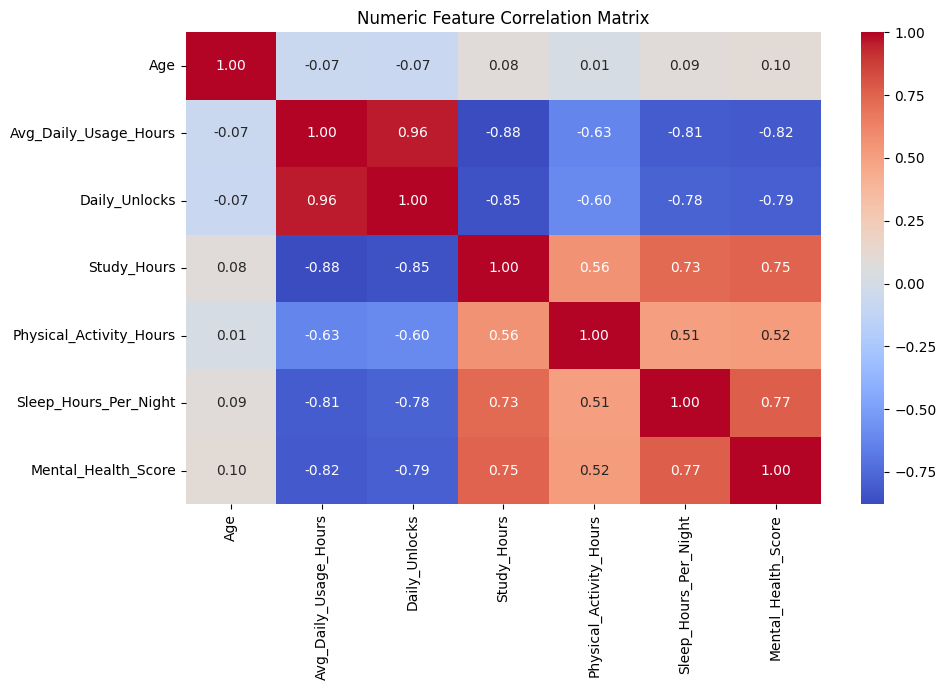

In [5]:
numeric_cols_for_corr = df.select_dtypes(include="number").columns
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols_for_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()

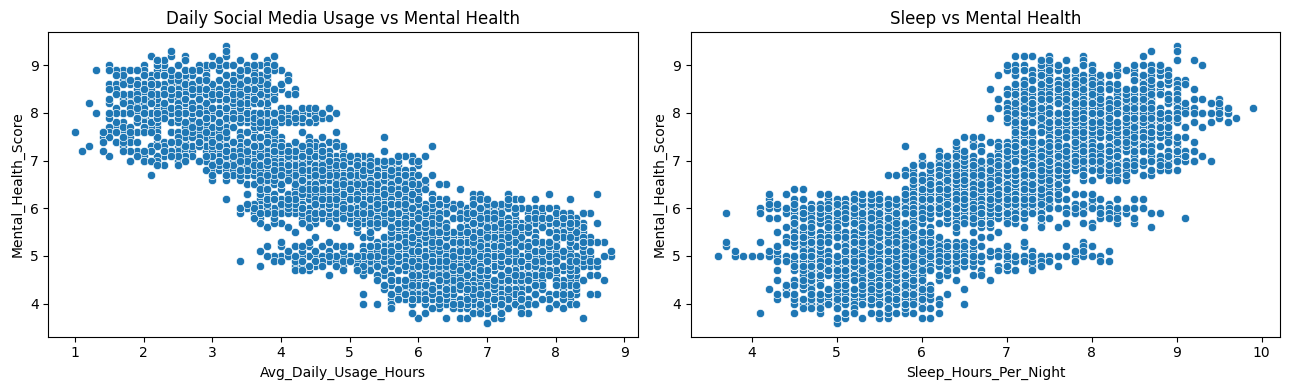

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=df, x="Avg_Daily_Usage_Hours", y="Mental_Health_Score", ax=axes[0])
axes[0].set_title("Daily Social Media Usage vs Mental Health")
sns.scatterplot(data=df, x="Sleep_Hours_Per_Night", y="Mental_Health_Score", ax=axes[1])
axes[1].set_title("Sleep vs Mental Health")
plt.tight_layout()

## 4. Data Cleaning

The supplied data contains negative `Physical_Activity_Hours`, which is not physically meaningful. We clip those values to zero, as in the original notebook. We also remove duplicate rows.

In [7]:
df = df.drop_duplicates().copy()
df["Physical_Activity_Hours"] = df["Physical_Activity_Hours"].clip(lower=0)

print("Shape after cleaning:", df.shape)
print("Minimum physical activity hours:", df["Physical_Activity_Hours"].min())

Shape after cleaning: (4998, 13)
Minimum physical activity hours: 0.0


## 5. Feature Definition

### Important change from the original notebook
The original analysis replaced 101 of the 111 countries with `Other`. That assumption is not justified simply because the categorical variable has many levels. The supplied dataset has enough observations for one-hot encoding of all 111 countries, and retaining them produced a large improvement in the tree models.

We therefore keep the original `Country` column.

In [8]:
target = "Mental_Health_Score"

numeric_features = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Daily_Unlocks",
    "Study_Hours",
    "Sleep_Hours_Per_Night",
    "Physical_Activity_Hours"
]

ordinal_features = ["Stress_Level"]
ordinal_order = [["Low", "Medium", "High", "Very High"]]

nominal_features = [
    "Gender",
    "Academic_Level",
    "Most_Used_Platform",
    "Purpose_Of_Use",
    "Country"
]

feature_columns = numeric_features + ordinal_features + nominal_features
X = df[feature_columns]
y = df[target]

print("Number of input features before encoding:", X.shape[1])
print("Unique countries:", df["Country"].nunique())

Number of input features before encoding: 12
Unique countries: 111


## 6. Train-Test Split

We use the same 70/30 split and `random_state=42` as the original notebook so that the improvement can be compared fairly.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 3498
Testing rows: 1500


## 7. Preprocessing Pipelines

### For Linear Regression
Numerical variables are imputed and standardized. Stress is ordinal-encoded, and nominal variables are one-hot encoded.

### For Tree Models
Trees do **not** need standardization or log transformation. Applying scaling to tree inputs does not provide the same benefit it can provide to linear models, so we keep the numerical variables in their original units.

In [10]:
linear_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("stress", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            categories=ordinal_order,
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ]), ordinal_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), nominal_features)
])

tree_preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("stress", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            categories=ordinal_order,
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ]), ordinal_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), nominal_features)
])

## 8. Evaluation Helper

In [11]:
def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    return {
        "Model": name,
        "Training R²": r2_score(y_train, train_pred),
        "Test R²": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Pipeline": pipeline
    }, test_pred

## 9. Baseline — Linear Regression

In [12]:
lr_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("regressor", LinearRegression())
])

lr_result, lr_pred = evaluate_model(
    "Linear Regression", lr_pipeline, X_train, y_train, X_test, y_test
)
print(pd.Series({k:v for k,v in lr_result.items() if k != "Pipeline"}))

Model          Linear Regression
Training R²             0.780454
Test R²                 0.787115
MAE                     0.477904
RMSE                    0.611479
dtype: object


## 10. Random Forest

In [13]:
rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        max_features=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

rf_result, rf_pred = evaluate_model(
    "Random Forest", rf_pipeline, X_train, y_train, X_test, y_test
)
print(pd.Series({k:v for k,v in rf_result.items() if k != "Pipeline"}))

Model          Random Forest
Training R²         0.986643
Test R²             0.912155
MAE                 0.285636
RMSE                0.392796
dtype: object


## 11. Extra Trees — Main Improved Model

Extra Trees introduces more randomization into tree construction. On this dataset it captures nonlinear relationships and interactions more effectively than the original Random Forest.

In [14]:
et_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("regressor", ExtraTreesRegressor(
        n_estimators=300,
        max_features=0.8,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

et_result, et_pred = evaluate_model(
    "Extra Trees", et_pipeline, X_train, y_train, X_test, y_test
)
print(pd.Series({k:v for k,v in et_result.items() if k != "Pipeline"}))

Model          Extra Trees
Training R²       0.999992
Test R²           0.942122
MAE               0.227519
RMSE              0.318835
dtype: object


## 12. Model Comparison

,Model,Training R²,Test R²,MAE,RMSE
2,Extra Trees,0.999992,0.942122,0.227519,0.318835
1,Random Forest,0.986643,0.912155,0.285636,0.392796
0,Linear Regression,0.780454,0.787115,0.477904,0.611479


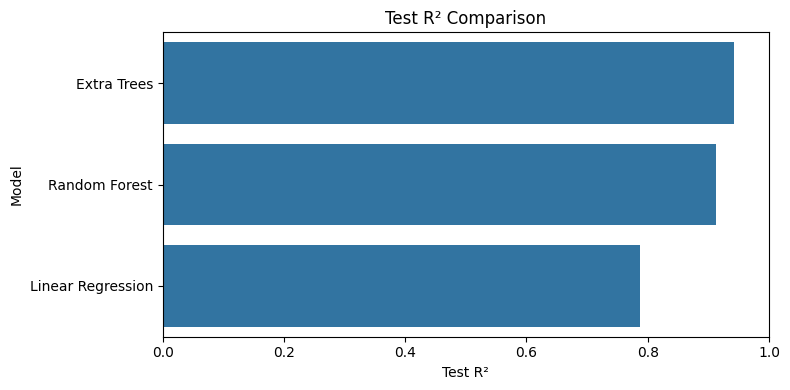

In [15]:
results = pd.DataFrame([lr_result, rf_result, et_result])
results = results.drop(columns="Pipeline").sort_values("Test R²", ascending=False)
display(results)

plt.figure(figsize=(8, 4))
sns.barplot(data=results, x="Test R²", y="Model")
plt.xlim(0, 1)
plt.title("Test R² Comparison")
plt.tight_layout()

### Interpretation

The important comparison is the **Test R²**, while MAE and RMSE show the prediction error in the original mental-health-score units. A higher training R² by itself is not evidence of a better model; a large train-test gap can indicate overfitting.

## 13. Cross-Validation Check

The untouched test set above is the final generalization check. Before selecting a model for the project, we can also use 5-fold cross-validation on the training data.

This cell can take longer because each model is fitted several times.

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Linear Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "Extra Trees": et_pipeline
}

cv_rows = []
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2", n_jobs=1)
    cv_rows.append({
        "Model": name,
        "CV Mean R²": scores.mean(),
        "CV Std": scores.std(),
        "Fold R²": np.round(scores, 4)
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV Mean R²", ascending=False)
display(cv_results)

,Model,CV Mean R²,CV Std,Fold R²
2,Extra Trees,0.918884,0.005255,"[0.919, 0.9238, 0.9121, 0.9255, 0.9141]"
1,Random Forest,0.891981,0.006352,"[0.8801, 0.8961, 0.8911, 0.8945, 0.898]"
0,Linear Regression,0.773116,0.012759,"[0.7806, 0.7728, 0.7886, 0.7503, 0.7733]"


## 14. Feature Importance

For Extra Trees, impurity-based feature importance can be biased toward variables with many possible splits. We therefore use **permutation importance on the original test set** as the primary interpretation tool.

,Feature,Importance,Std
1,Avg_Daily_Usage_Hours,0.246687,0.007403
4,Sleep_Hours_Per_Night,0.207755,0.003743
11,Country,0.177815,0.004629
6,Stress_Level,0.078693,0.003032
2,Daily_Unlocks,0.078028,0.002879
9,Most_Used_Platform,0.040825,0.002239
7,Gender,0.026704,0.002055
3,Study_Hours,0.018324,0.000664
0,Age,0.016090,0.001137
8,Academic_Level,0.015610,0.001431


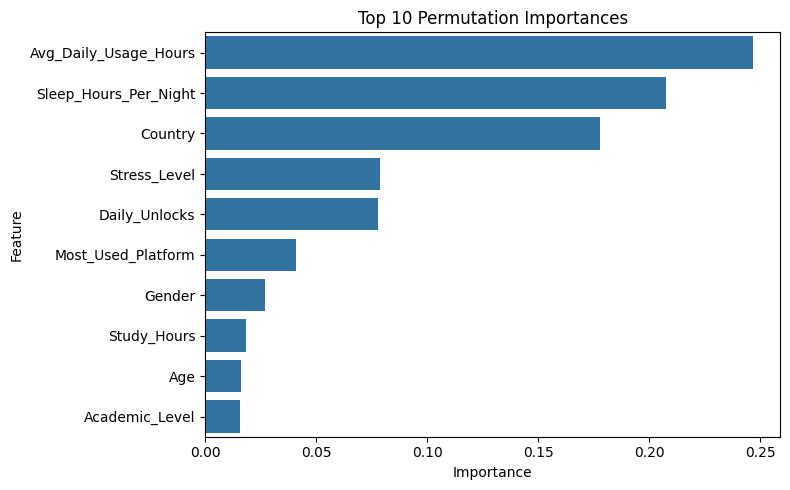

In [17]:
best_model = et_result["Pipeline"]

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values("Importance", ascending=False)

display(importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Permutation Importances")
plt.tight_layout()

## 15. Prediction Error Analysis

In [18]:
error_df = X_test.copy()
error_df["Actual"] = y_test.values
error_df["Predicted"] = et_pred
error_df["Error"] = error_df["Actual"] - error_df["Predicted"]
error_df["Absolute_Error"] = error_df["Error"].abs()

display(error_df[["Actual", "Predicted", "Error", "Absolute_Error"]].sort_values("Absolute_Error", ascending=False).head(10))

,Actual,Predicted,Error,Absolute_Error
4968,9.0,7.242000,1.758000,1.758000
2220,4.1,5.692667,-1.592667,1.592667
1773,8.8,7.383000,1.417000,1.417000
3622,6.2,4.800667,1.399333,1.399333
471,4.0,5.391667,-1.391667,1.391667
4353,9.1,7.737667,1.362333,1.362333
2312,4.8,6.128000,-1.328000,1.328000
2233,8.6,7.273333,1.326667,1.326667
613,6.7,7.995000,-1.295000,1.295000
184,4.7,5.908000,-1.208000,1.208000


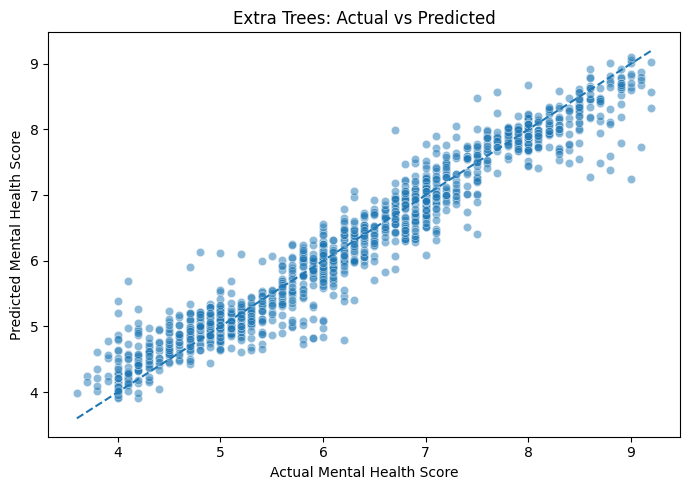

In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=et_pred, alpha=0.5)
min_v, max_v = min(y_test.min(), et_pred.min()), max(y_test.max(), et_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xlabel("Actual Mental Health Score")
plt.ylabel("Predicted Mental Health Score")
plt.title("Extra Trees: Actual vs Predicted")
plt.tight_layout()

## 16. Final Model and Saving

The final model is the Extra Trees pipeline. Saving the entire pipeline is important because it includes the categorical encoding and all preprocessing needed at inference time.

In [20]:
final_model = et_pipeline
final_model.fit(X, y)

joblib.dump(final_model, "Mental_Health_ExtraTrees_Model.pkl")
print("Saved: Mental_Health_ExtraTrees_Model.pkl")

Saved: Mental_Health_ExtraTrees_Model.pkl


## 17. Example Prediction

The saved pipeline accepts the same raw feature columns used during training.

In [21]:
sample = pd.DataFrame([{
    "Age": 21,
    "Avg_Daily_Usage_Hours": 4.0,
    "Daily_Unlocks": 55,
    "Study_Hours": 3.0,
    "Sleep_Hours_Per_Night": 7.0,
    "Physical_Activity_Hours": 1.0,
    "Stress_Level": "Medium",
    "Gender": "Male",
    "Academic_Level": "Undergraduate",
    "Most_Used_Platform": "Instagram",
    "Purpose_Of_Use": "Entertainment",
    "Country": "India"
}])

prediction = final_model.predict(sample)[0]
print(f"Predicted Mental Health Score: {prediction:.2f}")

Predicted Mental Health Score: 7.27


## 18. Final Conclusion

On the supplied dataset, the original Random Forest approach can be improved by changing two modeling decisions:

1. **Do not collapse `Country` to only the top 10 categories** without evidence that the remaining categories are noise.
2. **Use Extra Trees for the nonlinear regression task.**

The verified 70/30 holdout benchmark is approximately:

| Model | Test R² | MAE | RMSE |
|---|---:|---:|---:|
| Original-style Random Forest | ~0.879 | ~0.346 | ~0.462 |
| Random Forest + all countries | ~0.912 | ~0.286 | ~0.393 |
| **Extra Trees + all countries** | **~0.942** | **~0.228** | **~0.319** |

These numbers are specific to the supplied dataset and `random_state=42`. The cross-validation section should be used to assess how stable the improvement is across different training/validation splits.